In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import re

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     learning_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import (GaussianNB, MultinomialNB,
                                 BernoulliNB, ComplementNB)
from sklearn.feature_extraction.text import (TfidfVectorizer,
                                             CountVectorizer)
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [2]:
path = kagglehub.dataset_download(
    "uciml/sms-spam-collection-dataset")
print("📁 Path to dataset files:", path)

csv_file = os.path.join(path, "spam.csv")
df = pd.read_csv(csv_file,
                 encoding='latin-1')

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
📁 Path to dataset files: /kaggle/input/sms-spam-collection-dataset

✅ Dataset Loaded!
📐 Shape: 5572 rows × 5 columns


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [5]:
print(df['v1'].value_counts())

v1
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
df['v1'].unique()

array(['ham', 'spam'], dtype=object)

In [7]:
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']
print("✅ Renamed columns: v1→label, v2→message")

✅ Renamed columns: v1→label, v2→message


In [8]:
print(f"\n🔍 Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])
    df.dropna(inplace=True)
    print("✅ Missing rows dropped")


🔍 Missing Values:
✅ No missing values found!


In [9]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ {dups} duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 403
✅ 403 duplicates removed!


In [10]:
df['label']   = df['label'].str.strip()
df['message'] = df['message'].str.strip()
print("✅ Whitespace stripped")

✅ Whitespace stripped


In [11]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
# ham=0, spam=1
print(f"\n✅ Label Encoding:")
for cls, enc in zip(le.classes_,
                    le.transform(le.classes_)):
    print(f"   {cls} → {enc}")

print(f"\n📐 Cleaned Shape: {df.shape}")
df.head(5)


✅ Label Encoding:
   ham → 0
   spam → 1

📐 Cleaned Shape: (5169, 3)


,label,message,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [12]:
df['msg_length']    = df['message'].apply(len)
df['word_count']    = df['message'].apply(
    lambda x: len(x.split()))
df['char_count']    = df['message'].apply(
    lambda x: len(x.replace(' ', '')))
df['digit_count']   = df['message'].apply(
    lambda x: sum(c.isdigit() for c in x))
df['upper_count']   = df['message'].apply(
    lambda x: sum(c.isupper() for c in x))
df['special_count'] = df['message'].apply(
    lambda x: sum(not c.isalnum()
                  for c in x))
df['exclaim_count'] = df['message'].apply(
    lambda x: x.count('!'))
df['question_count']= df['message'].apply(
    lambda x: x.count('?'))
df['url_count']     = df['message'].apply(
    lambda x: len(re.findall(
        r'http[s]?://\S+|www\.\S+', x)))
df['digit_ratio']   = (df['digit_count'] /
                        (df['msg_length'] + 1))
df['upper_ratio']   = (df['upper_count'] /
                        (df['msg_length'] + 1))
df['avg_word_len']  = (df['char_count'] /
                        (df['word_count'] + 1))

print("✅ Text features created:")
text_features = ['msg_length', 'word_count',
                 'char_count', 'digit_count',
                 'upper_count', 'special_count',
                 'exclaim_count', 'question_count',
                 'url_count', 'digit_ratio',
                 'upper_ratio', 'avg_word_len']
for f in text_features:
    print(f"   → {f}")

print(f"\n📐 Shape with text features: {df.shape}")
df[['label', 'message'] + text_features].head(3)

✅ Text features created:
   → msg_length
   → word_count
   → char_count
   → digit_count
   → upper_count
   → special_count
   → exclaim_count
   → question_count
   → url_count
   → digit_ratio
   → upper_ratio
   → avg_word_len

📐 Shape with text features: (5169, 15)


,label,message,msg_length,word_count,char_count,digit_count,upper_count,special_count,exclaim_count,question_count,url_count,digit_ratio,upper_ratio,avg_word_len
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,92,0,3,28,0,0,0,0.000000,0.026786,4.380952
1,ham,Ok lar... Joking wif u oni...,29,6,24,0,2,11,0,0,0,0.000000,0.066667,3.428571
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,128,25,10,33,0,0,0,0.160256,0.064103,4.413793


In [13]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    # Remove phone numbers
    text = re.sub(r'\b\d{10,}\b', ' phone ', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)
print("✅ Text cleaning applied:")
print("   → Lowercase")
print("   → URLs replaced with 'url'")
print("   → Phone numbers replaced with 'phone'")
print("   → Special characters removed")
print("   → Extra spaces removed")

print("\n📌 Sample Before vs After Cleaning:")
for i in range(3):
    print(f"\n  Original : {df['message'].iloc[i][:60]}...")
    print(f"  Cleaned  : "
          f"{df['clean_message'].iloc[i][:60]}...")

✅ Text cleaning applied:
   → Lowercase
   → URLs replaced with 'url'
   → Phone numbers replaced with 'phone'
   → Special characters removed
   → Extra spaces removed

📌 Sample Before vs After Cleaning:

  Original : Go until jurong point, crazy.. Available only in bugis n gre...
  Cleaned  : go until jurong point crazy available only in bugis n great ...

  Original : Ok lar... Joking wif u oni......
  Cleaned  : ok lar joking wif u oni...

  Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st Ma...
  Cleaned  : free entry in a wkly comp to win fa cup final tkts st may te...


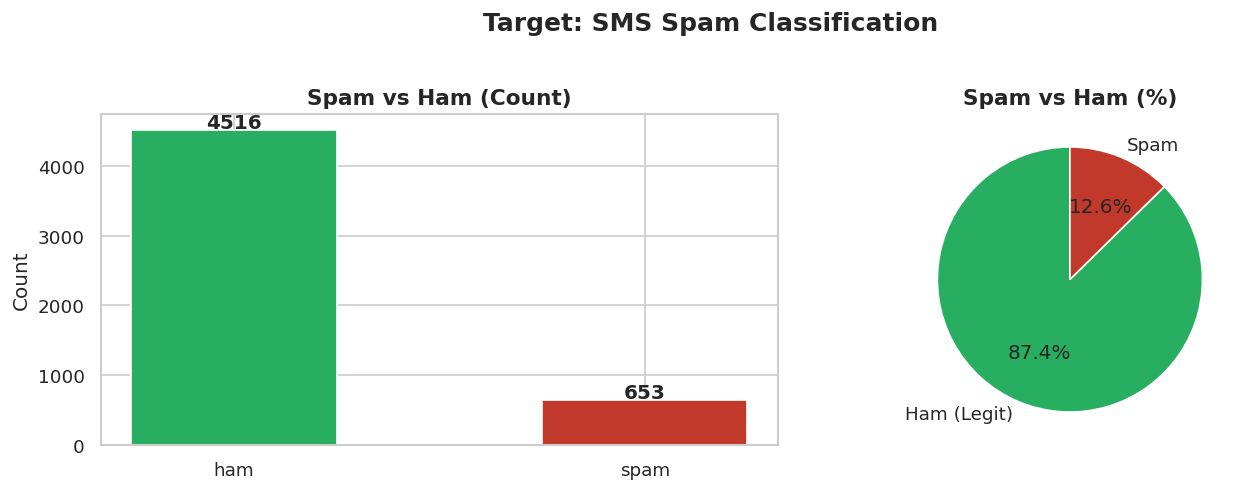

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df['label'].value_counts()

axes[0].bar(label_counts.index,
            label_counts.values,
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.5)
axes[0].set_title('Spam vs Ham (Count)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 20, str(v),
                 ha='center', fontweight='bold')

axes[1].pie(label_counts.values,
            labels=['Ham (Legit)', 'Spam'],
            autopct='%1.1f%%',
            colors=['#27ae60', '#c0392b'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Spam vs Ham (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target: SMS Spam Classification',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('NB_01_spam_distribution.png',
            bbox_inches='tight')
plt.show()

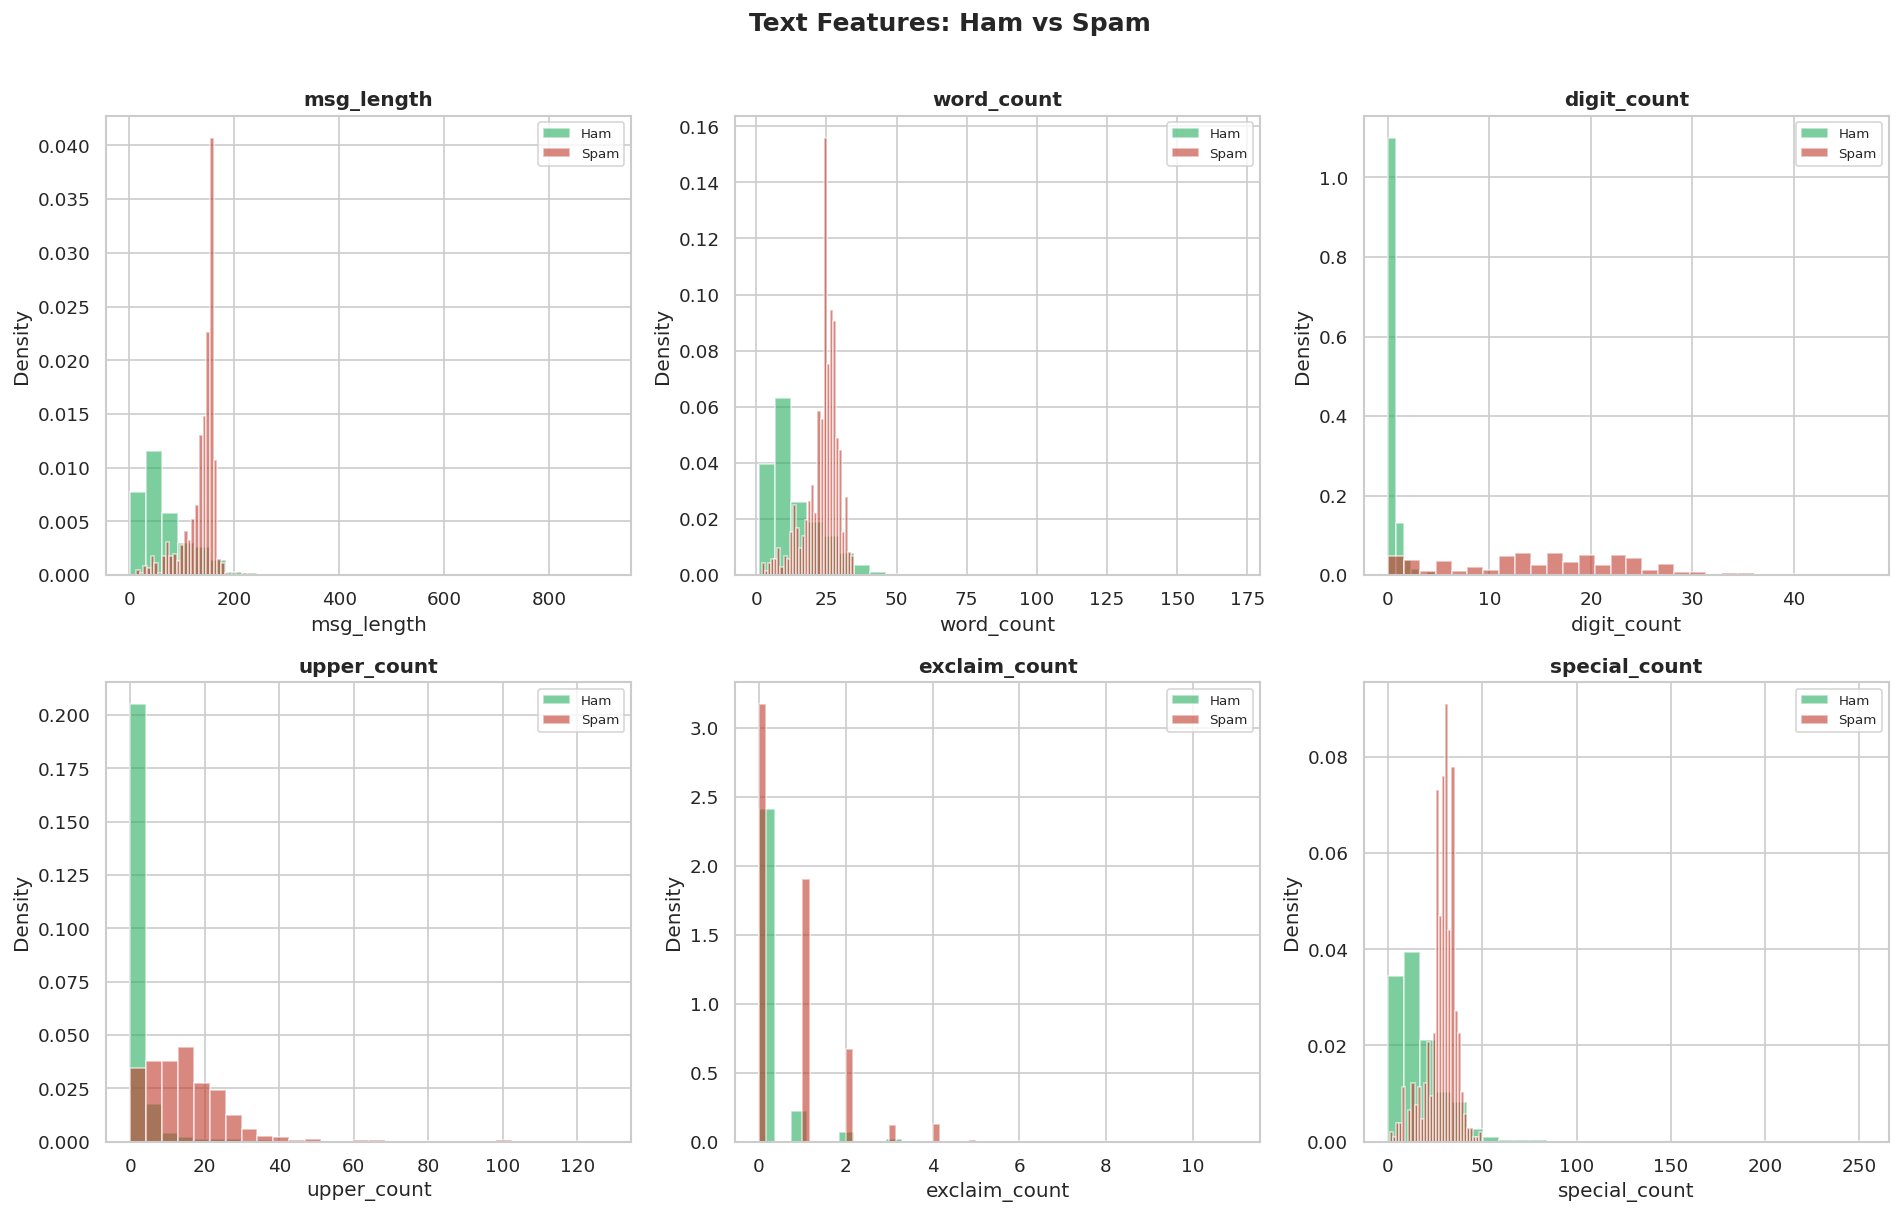

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_features = ['msg_length', 'word_count',
                 'digit_count', 'upper_count',
                 'exclaim_count', 'special_count']

for i, feat in enumerate(plot_features):
    axes[i].hist(
        df[df['label'] == 'ham'][feat],
        bins=30, alpha=0.6, color='#27ae60',
        label='Ham', density=True)
    axes[i].hist(
        df[df['label'] == 'spam'][feat],
        bins=30, alpha=0.6, color='#c0392b',
        label='Spam', density=True)
    axes[i].set_title(f'{feat}',
                      fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Text Features: Ham vs Spam',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('NB_02_feature_distributions.png',
            bbox_inches='tight')
plt.show()

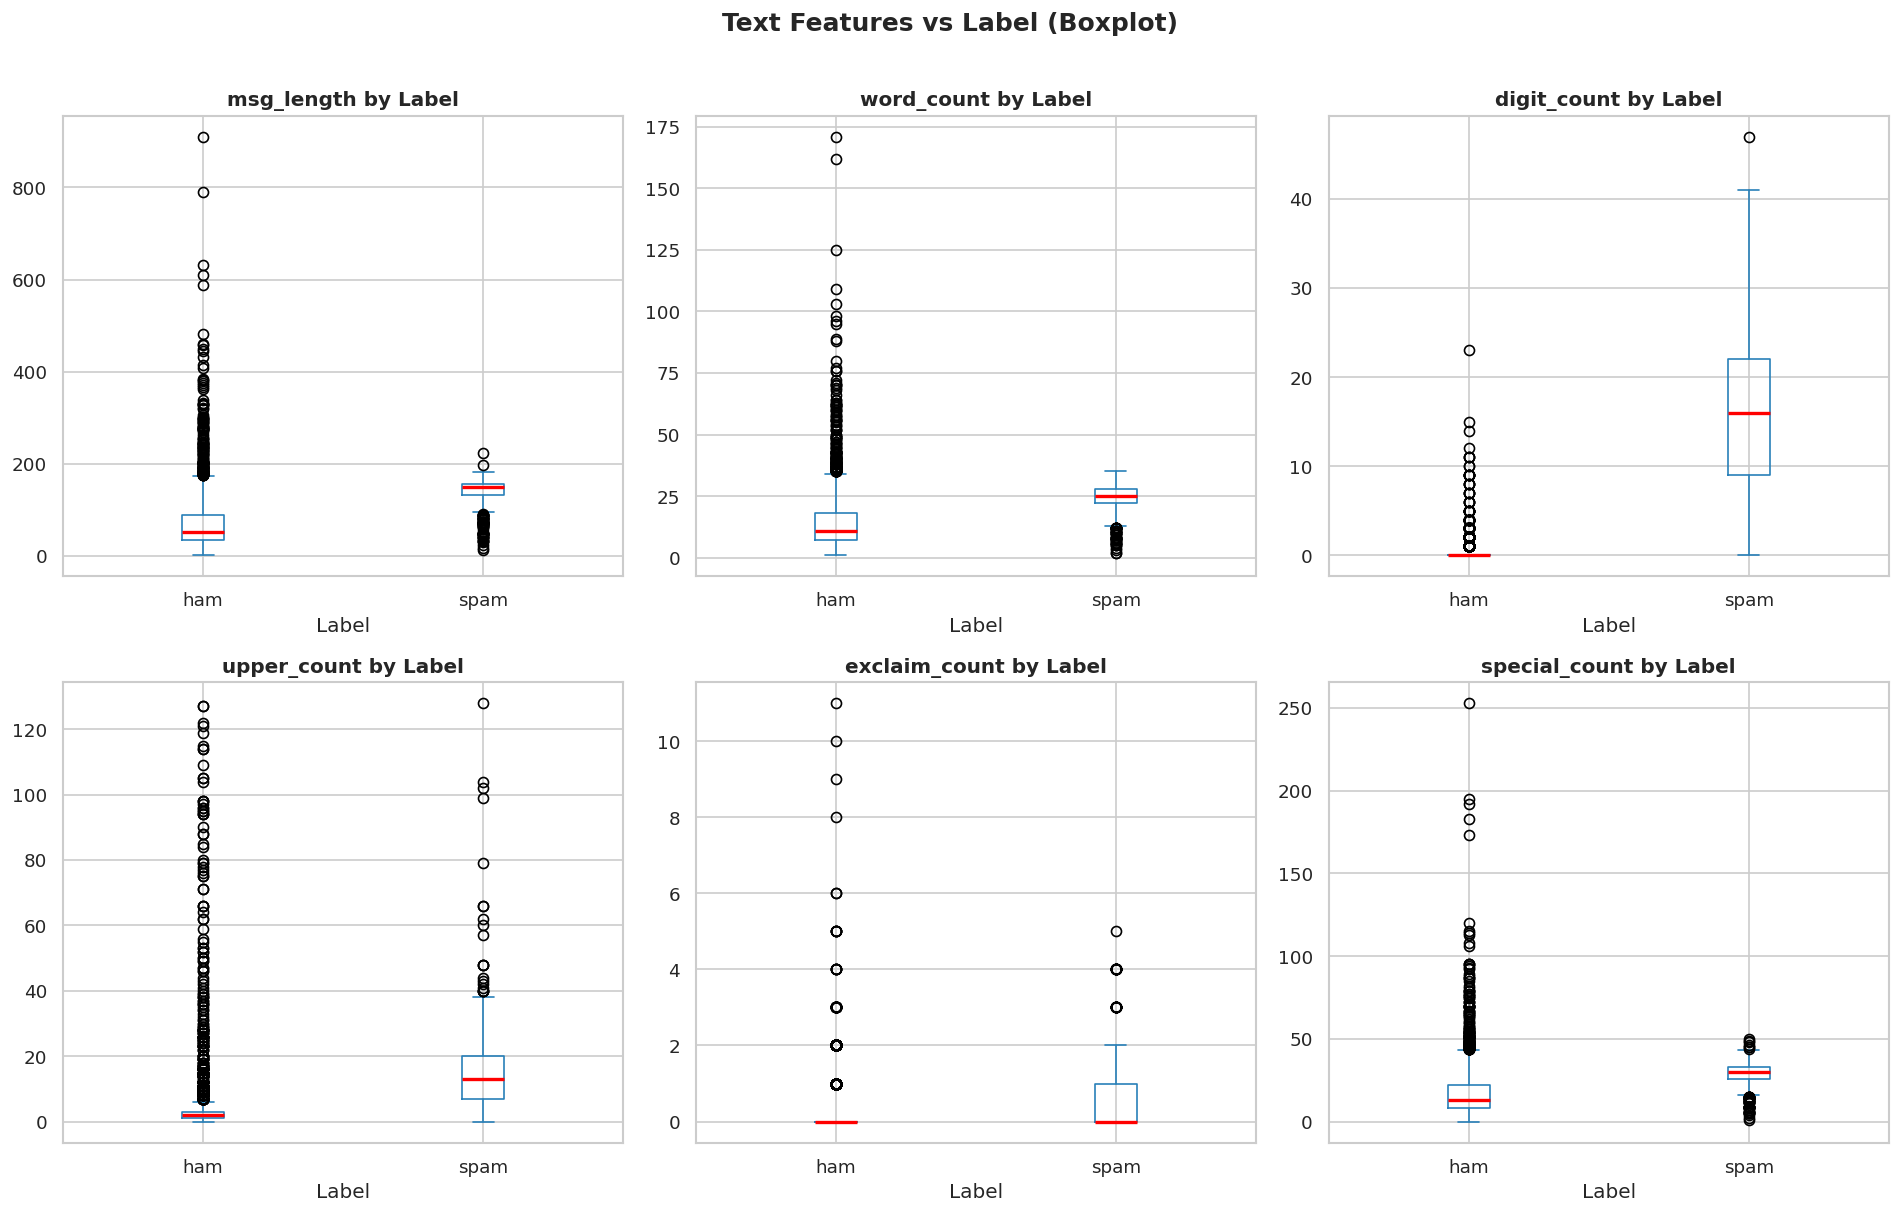

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    df.boxplot(column=feat, by='label',
               ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red',
                                linewidth=2),
               whiskerprops=dict(color='#2980b9'),
               capprops=dict(color='#2980b9'))
    axes[i].set_title(f'{feat} by Label',
                      fontweight='bold')
    axes[i].set_xlabel('Label')

plt.suptitle('Text Features vs Label (Boxplot)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('NB_03_boxplots.png', bbox_inches='tight')
plt.show()

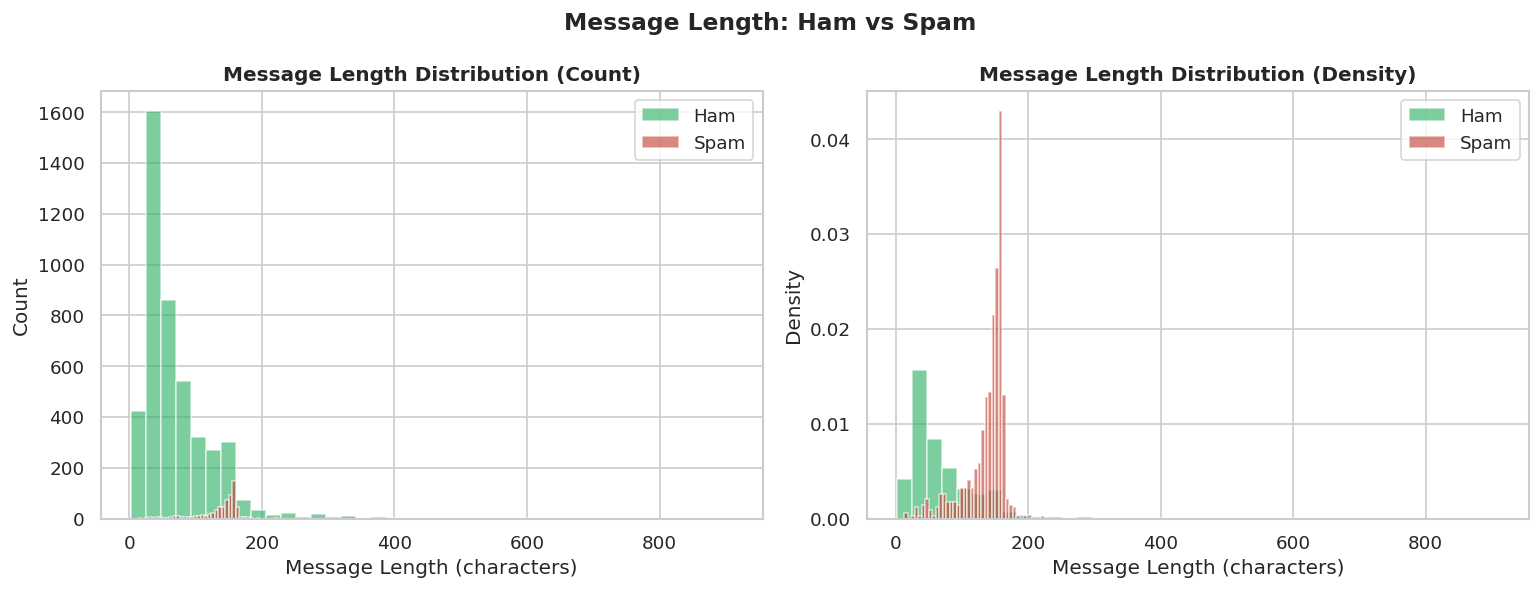

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, color in zip(['ham', 'spam'],
                         ['#27ae60', '#c0392b']):
    data = df[df['label'] == label]['msg_length']
    axes[0].hist(data, bins=40, alpha=0.6,
                 color=color, label=label.title())
    axes[1].hist(data, bins=40, alpha=0.6,
                 color=color, label=label.title(),
                 density=True)

for ax in axes:
    ax.legend()
    ax.set_xlabel('Message Length (characters)')

axes[0].set_title('Message Length Distribution (Count)',
                  fontweight='bold')
axes[0].set_ylabel('Count')
axes[1].set_title('Message Length Distribution (Density)',
                  fontweight='bold')
axes[1].set_ylabel('Density')

plt.suptitle('Message Length: Ham vs Spam',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('NB_04_message_length.png',
            bbox_inches='tight')
plt.show()

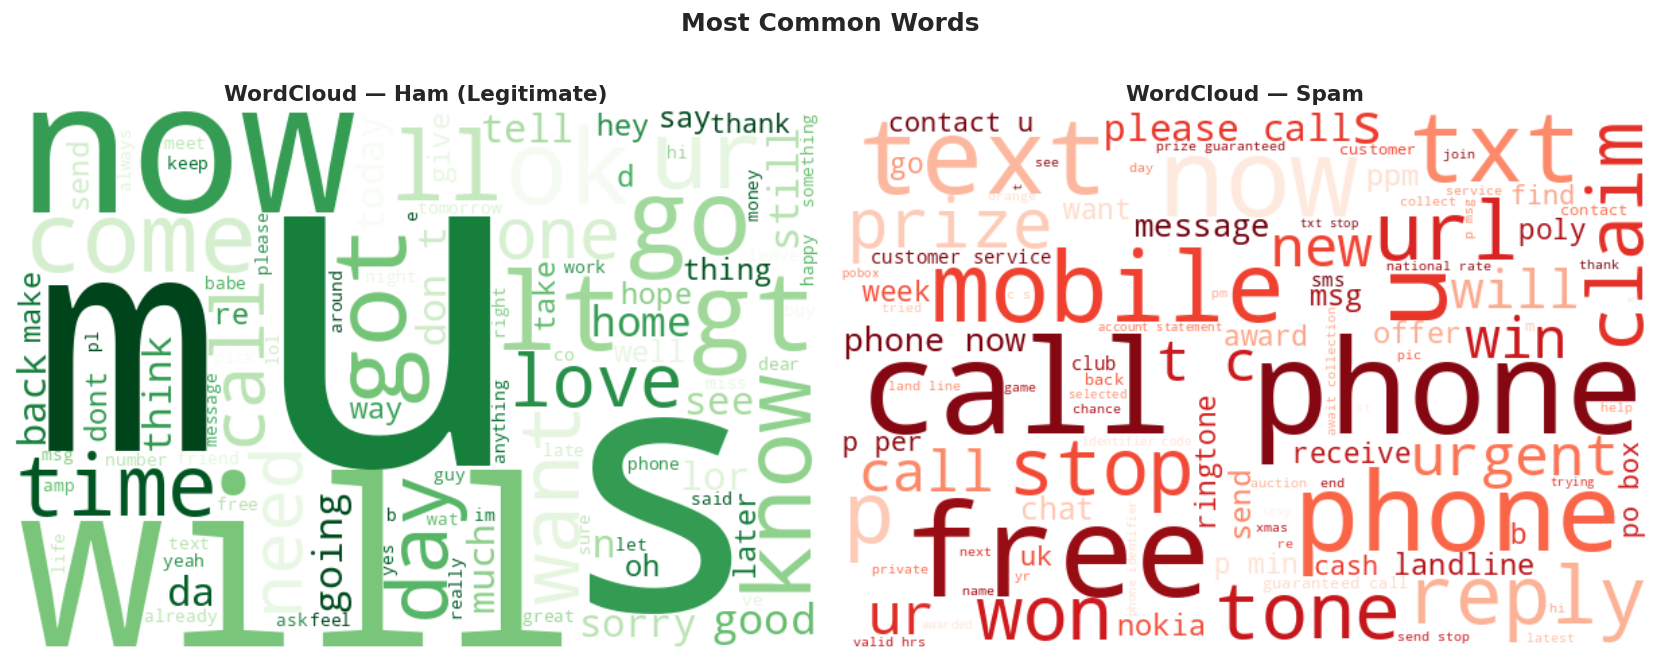

In [18]:
try:
    from wordcloud import WordCloud
    has_wordcloud = True
except ImportError:
    has_wordcloud = False
    print("⚠️  WordCloud not installed")
    print("   Run: pip install wordcloud")

if has_wordcloud:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, label, color, title in zip(
            axes,
            ['ham', 'spam'],
            ['Greens', 'Reds'],
            ['Ham (Legitimate)', 'Spam']):
        text = ' '.join(
            df[df['label'] == label]['clean_message'])
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=color,
            max_words=100).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'WordCloud — {title}',
                     fontsize=13, fontweight='bold')

    plt.suptitle('Most Common Words',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('NB_05_wordcloud.png',
                bbox_inches='tight')
    plt.show()

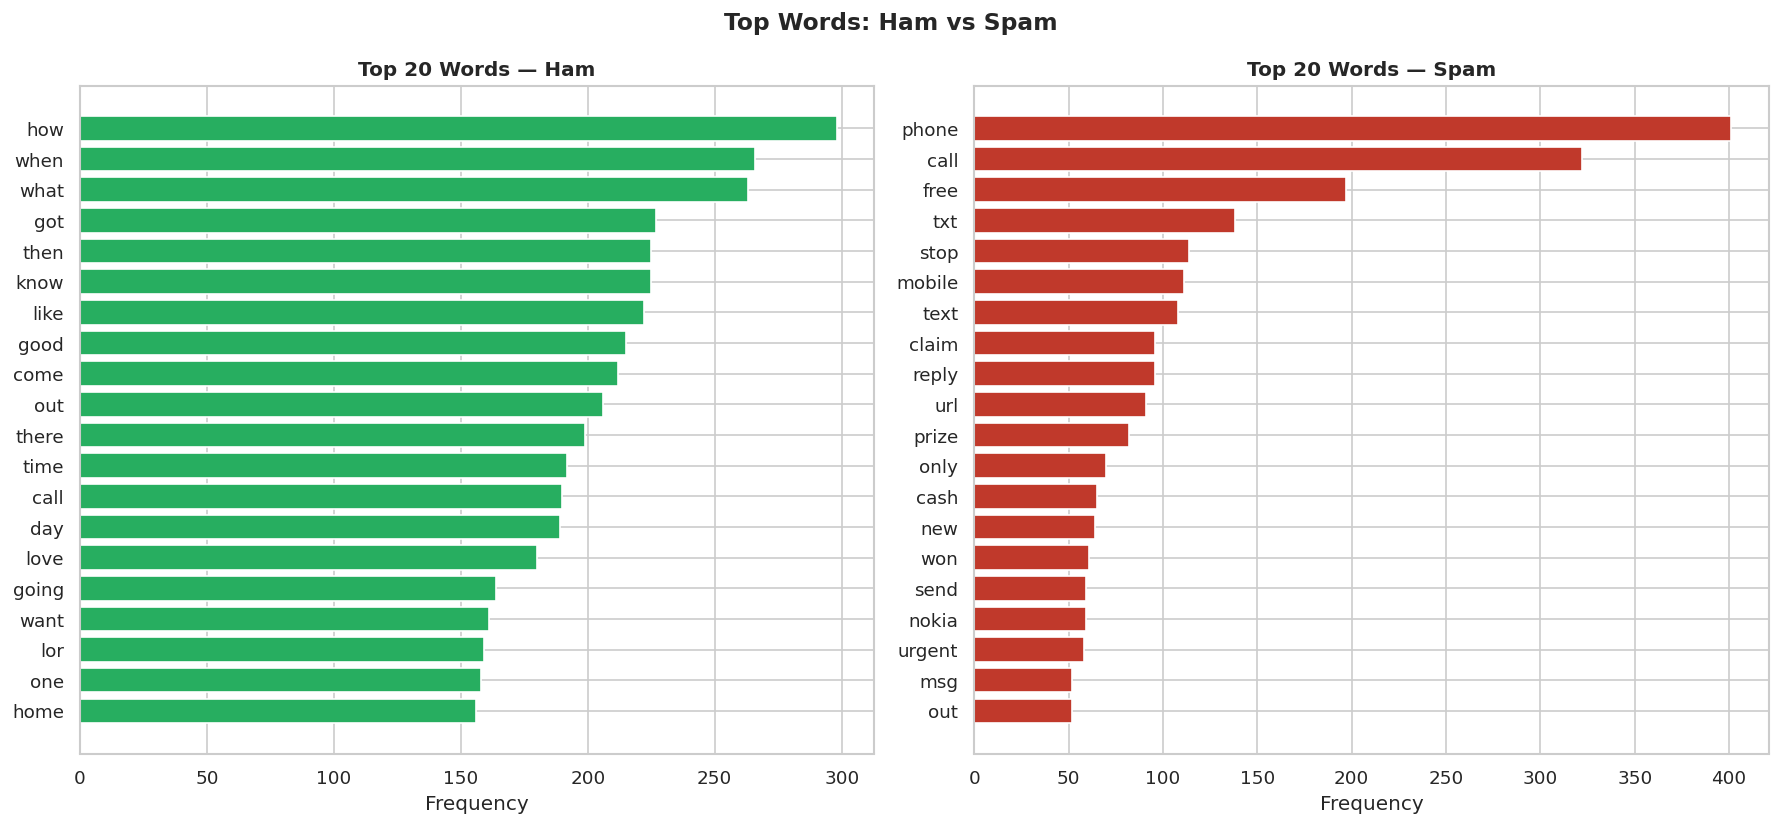

In [19]:
from collections import Counter

def get_top_words(label, n=20):
    words = ' '.join(
        df[df['label'] == label]['clean_message']
    ).split()
    # Remove stopwords manually
    stopwords = {
        'the', 'a', 'an', 'and', 'or', 'but',
        'in', 'on', 'at', 'to', 'for', 'of',
        'is', 'it', 'i', 'you', 'me', 'my',
        'we', 'he', 'she', 'they', 'that',
        'this', 'with', 'have', 'be', 'not',
        'are', 'was', 'do', 'will', 'your',
        'up', 'so', 'if', 'just', 'can',
        'get', 'all', 'now', 'its', 'our',
        'from', 'about', 'as', 'no', 'had'
    }
    words = [w for w in words
             if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

ham_words  = get_top_words('ham',  20)
spam_words = get_top_words('spam', 20)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Ham top words
words_h, counts_h = zip(*ham_words)
axes[0].barh(words_h, counts_h,
             color='#27ae60', edgecolor='white')
axes[0].set_title('Top 20 Words — Ham',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Spam top words
words_s, counts_s = zip(*spam_words)
axes[1].barh(words_s, counts_s,
             color='#c0392b', edgecolor='white')
axes[1].set_title('Top 20 Words — Spam',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.suptitle('Top Words: Ham vs Spam',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('NB_06_top_words.png', bbox_inches='tight')
plt.show()

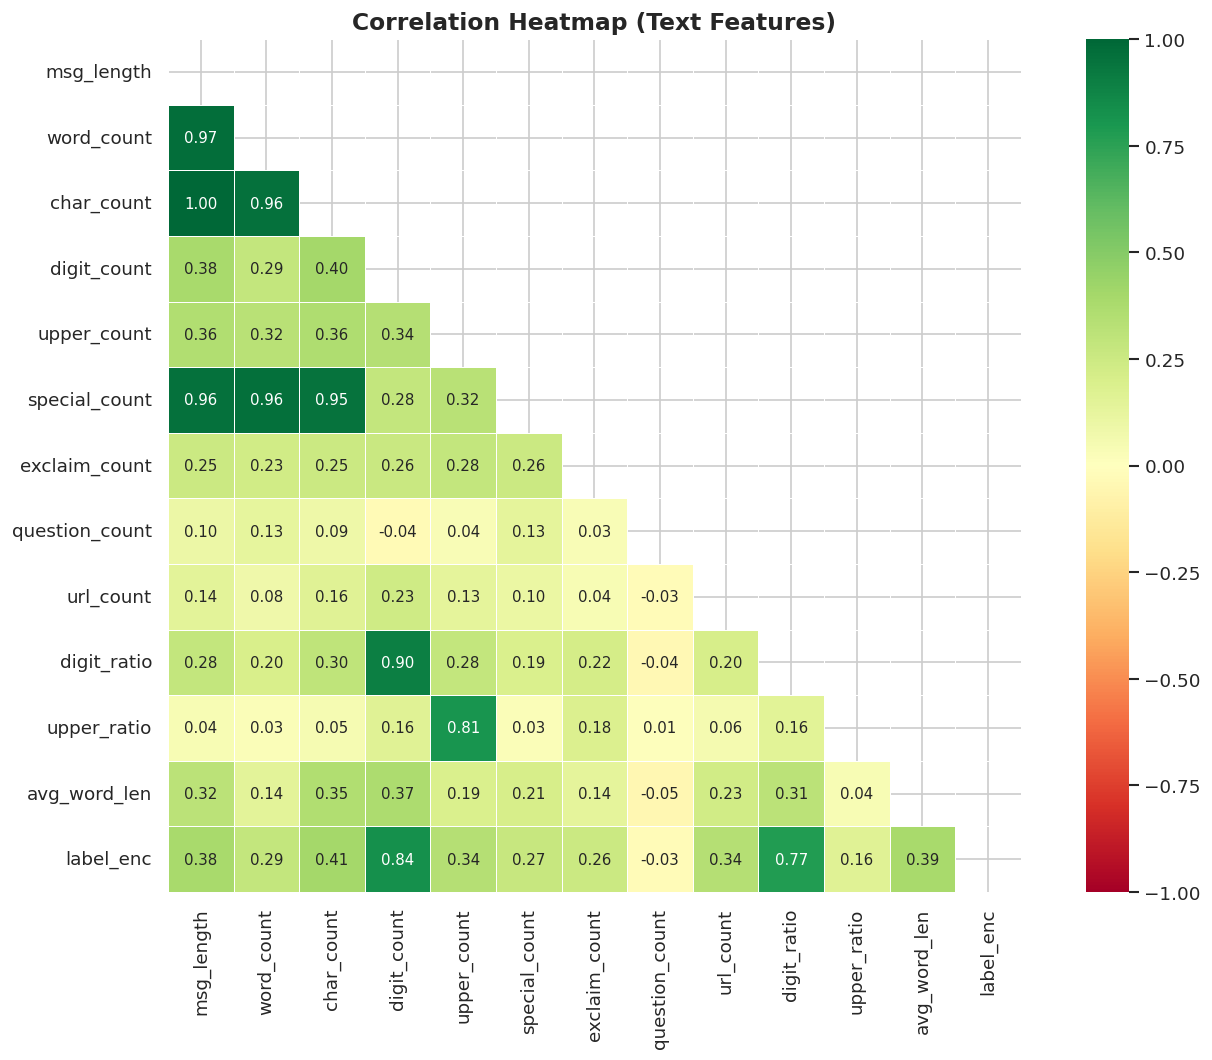

In [20]:
fig, ax = plt.subplots(figsize=(12, 9))

corr_df = df[text_features + ['label_enc']].corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(corr_df, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.4,
            ax=ax, annot_kws={'fontsize': 9},
            vmin=-1, vmax=1, center=0,
            square=True)
ax.set_title('Correlation Heatmap (Text Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('NB_07_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

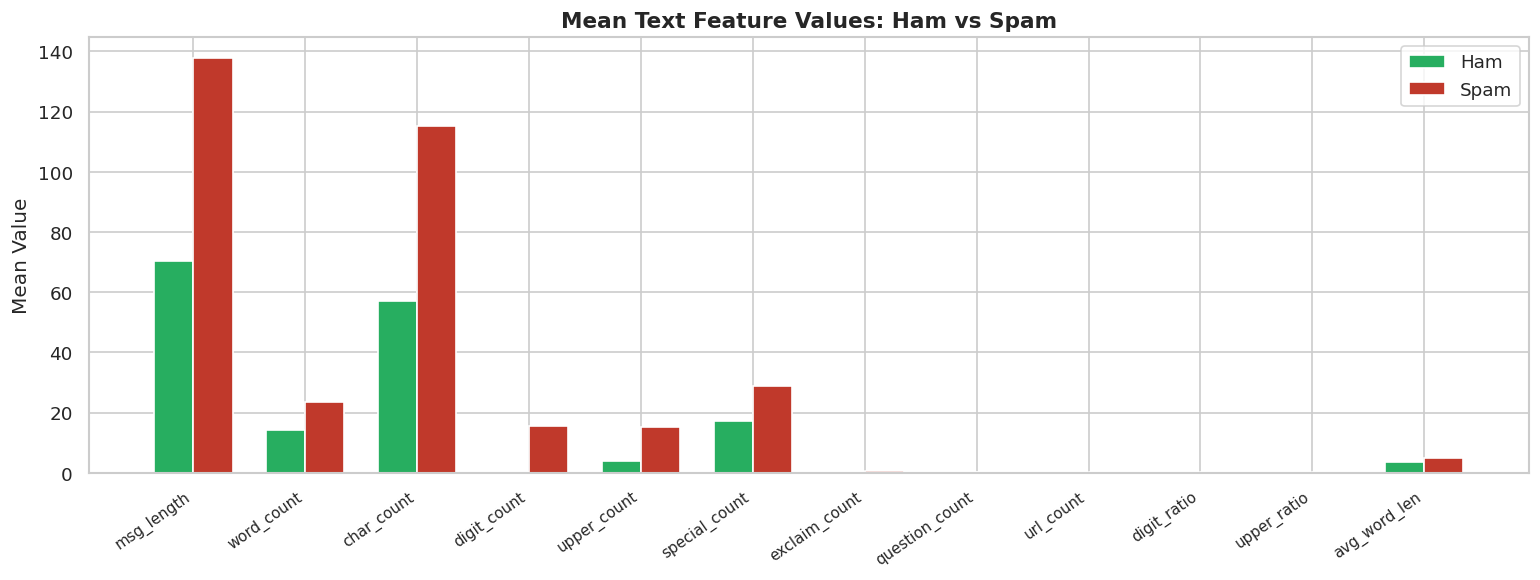

In [21]:
feat_stats = df.groupby('label')[text_features].mean()

fig, ax = plt.subplots(figsize=(13, 5))

x     = np.arange(len(text_features))
width = 0.35

bars1 = ax.bar(x - width/2,
               feat_stats.loc['ham'],
               width, label='Ham',
               color='#27ae60', edgecolor='white')
bars2 = ax.bar(x + width/2,
               feat_stats.loc['spam'],
               width, label='Spam',
               color='#c0392b', edgecolor='white')

ax.set_title('Mean Text Feature Values: Ham vs Spam',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(text_features,
                   rotation=35, ha='right',
                   fontsize=9)
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.savefig('NB_08_feature_stats.png',
            bbox_inches='tight')
plt.show()

In [22]:
X_text = df['clean_message']
y      = df['label_enc']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y)

print(f"✅ Training samples : {len(X_train_text)}")
print(f"✅ Test samples     : {len(X_test_text)}")
print(f"\n🎯 Train target:")
print(pd.Series(y_train).value_counts()
      .rename(index={0:'ham', 1:'spam'}))
print(f"\n🎯 Test target:")
print(pd.Series(y_test).value_counts()
      .rename(index={0:'ham', 1:'spam'}))

✅ Training samples : 4135
✅ Test samples     : 1034

🎯 Train target:
label_enc
ham     3613
spam     522
Name: count, dtype: int64

🎯 Test target:
label_enc
ham     903
spam    131
Name: count, dtype: int64


In [23]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Count Vectorizer (for MultinomialNB)
count_vec = CountVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95)

X_train_count = count_vec.fit_transform(X_train_text)
X_test_count  = count_vec.transform(X_test_text)

print(f"✅ TF-IDF shape  : {X_train_tfidf.shape}")
print(f"✅ CountVec shape: {X_train_count.shape}")
print(f"✅ Vocabulary size: {len(tfidf.vocabulary_)}")

✅ TF-IDF shape  : (4135, 5000)
✅ CountVec shape: (4135, 5000)
✅ Vocabulary size: 5000


In [24]:
nb_models = {
    'MultinomialNB (TF-IDF)': {
        'model': MultinomialNB(),
        'X_train': X_train_tfidf,
        'X_test' : X_test_tfidf
    },
    'MultinomialNB (Count)': {
        'model': MultinomialNB(),
        'X_train': X_train_count,
        'X_test' : X_test_count
    },
    'BernoulliNB (TF-IDF)': {
        'model': BernoulliNB(),
        'X_train': X_train_tfidf,
        'X_test' : X_test_tfidf
    },
    'ComplementNB (TF-IDF)': {
        'model': ComplementNB(),
        'X_train': X_train_tfidf,
        'X_test' : X_test_tfidf
    }
}

variant_results = {}

for name, config in nb_models.items():
    model   = config['model']
    X_tr    = config['X_train']
    X_te    = config['X_test']

    model.fit(X_tr, y_train)
    y_p  = model.predict(X_te)
    y_pp = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_test, y_p)
    roc = roc_auc_score(y_test, y_pp)
    cv  = cross_val_score(
        model, X_tr, y_train,
        cv=StratifiedKFold(5),
        scoring='roc_auc').mean()

    variant_results[name] = {
        'model': model,
        'acc'  : acc,
        'roc'  : roc,
        'cv'   : cv,
        'X_train': X_tr,
        'X_test' : X_te
    }

    print(f"  {name:<35} → "
          f"Acc: {acc*100:.2f}%  "
          f"ROC: {roc:.4f}  "
          f"CV: {cv:.4f}")

best_variant = max(variant_results,
                   key=lambda k: variant_results[k]['roc'])
print(f"\n🏆 Best Variant: {best_variant}")

  MultinomialNB (TF-IDF)              → Acc: 96.91%  ROC: 0.9896  CV: 0.9843
  MultinomialNB (Count)               → Acc: 98.74%  ROC: 0.9822  CV: 0.9777
  BernoulliNB (TF-IDF)                → Acc: 98.26%  ROC: 0.9953  CV: 0.9940
  ComplementNB (TF-IDF)               → Acc: 98.16%  ROC: 0.9896  CV: 0.9843

🏆 Best Variant: BernoulliNB (TF-IDF)


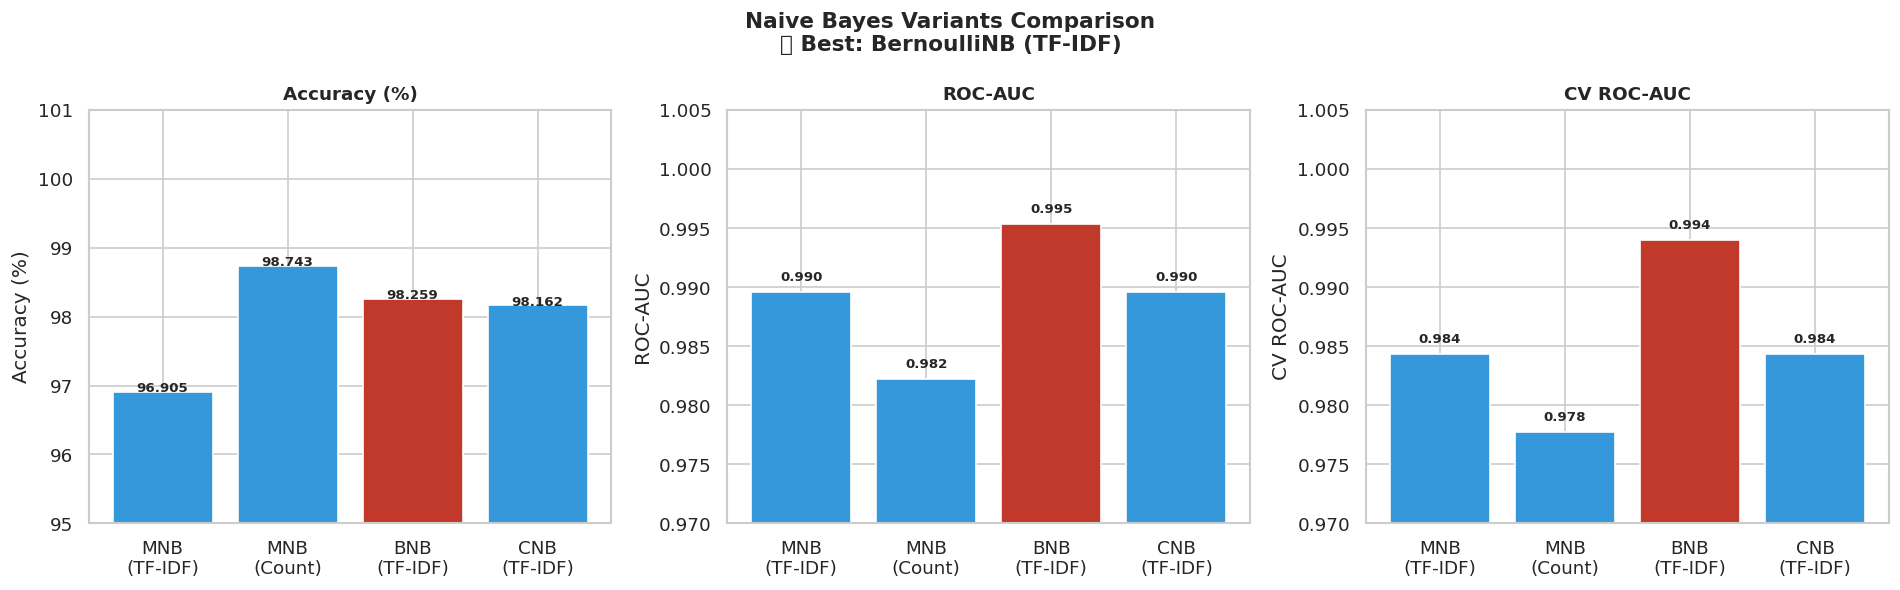

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names  = list(variant_results.keys())
accs   = [variant_results[n]['acc'] * 100 for n in names]
rocs   = [variant_results[n]['roc'] for n in names]
cvs    = [variant_results[n]['cv']  for n in names]
colors = ['#c0392b' if n == best_variant
          else '#3498db' for n in names]

short_names = ['MNB\n(TF-IDF)', 'MNB\n(Count)',
               'BNB\n(TF-IDF)', 'CNB\n(TF-IDF)']

for ax, values, title, ylim in zip(
        axes,
        [accs, rocs, cvs],
        ['Accuracy (%)', 'ROC-AUC', 'CV ROC-AUC'],
        [(95, 101), (0.97, 1.005), (0.97, 1.005)]):
    bars = ax.bar(short_names, values,
                  color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(title)
    ax.set_ylim(ylim)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.3f}',
                ha='center', fontsize=8,
                fontweight='bold')

plt.suptitle('Naive Bayes Variants Comparison\n'
             f'🏆 Best: {best_variant}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('NB_09_variant_comparison.png',
            bbox_inches='tight')
plt.show()

In [26]:
if 'Complement' in best_variant:
    nb_estimator = ComplementNB()
    param_grid = {
        'vectorizer__max_features': [3000, 5000, 8000],
        'vectorizer__ngram_range' : [(1,1), (1,2), (1,3)],
        'vectorizer__min_df'      : [1, 2, 3],
        'nb__alpha'               : [0.01, 0.1,
                                     0.5, 1.0, 2.0]
    }
elif 'Bernoulli' in best_variant:
    nb_estimator = BernoulliNB()
    param_grid = {
        'vectorizer__max_features': [3000, 5000, 8000],
        'vectorizer__ngram_range' : [(1,1), (1,2)],
        'nb__alpha'               : [0.01, 0.1,
                                     0.5, 1.0, 2.0],
        'nb__binarize'            : [0.0, 0.1, 0.5]
    }
else:
    nb_estimator = MultinomialNB()
    param_grid = {
        'vectorizer__max_features': [3000, 5000, 8000],
        'vectorizer__ngram_range' : [(1,1), (1,2), (1,3)],
        'vectorizer__min_df'      : [1, 2, 3],
        'nb__alpha'               : [0.01, 0.1,
                                     0.5, 1.0, 2.0]
    }

# Use TF-IDF for tuning
nb_pipeline_tune = Pipeline([
    ('vectorizer', TfidfVectorizer(
        sublinear_tf=True,
        max_df=0.95)),
    ('nb', nb_estimator)
])

grid_search = GridSearchCV(
    estimator  = nb_pipeline_tune,
    param_grid = param_grid,
    cv         = StratifiedKFold(5),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train_text, y_train)

print(f"\n✅ Best Parameters  : {grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC  : "
      f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

✅ Best Parameters  : {'nb__alpha': 1.0, 'nb__binarize': 0.0, 'vectorizer__max_features': 8000, 'vectorizer__ngram_range': (1, 2)}
✅ Best CV ROC-AUC  : 0.9941


In [27]:
nb_best = grid_search.best_estimator_
nb_best.fit(X_train_text, y_train)

y_pred      = nb_best.predict(X_test_text)
y_pred_prob = nb_best.predict_proba(X_test_text)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)
cv  = cross_val_score(
    nb_best, X_train_text, y_train,
    cv=StratifiedKFold(5),
    scoring='roc_auc')

# Baseline (default MultinomialNB)
nb_base = Pipeline([
    ('vec', TfidfVectorizer()),
    ('nb',  MultinomialNB())])
nb_base.fit(X_train_text, y_train)
acc_base = accuracy_score(
    y_test, nb_base.predict(X_test_text))
roc_base = roc_auc_score(
    y_test,
    nb_base.predict_proba(X_test_text)[:, 1])

print(f"\n{'Metric':<28} {'Baseline':>10} {'Tuned':>10}")
print("-" * 50)
print(f"{'Accuracy':<28} "
      f"{acc_base*100:>9.2f}% {acc*100:>9.2f}%")
print(f"{'ROC-AUC':<28} "
      f"{roc_base:>10.4f} {roc:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<28} "
      f"{'—':>10} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<28} "
      f"{'—':>10} {cv.std():>10.4f}")

print(f"\n📋 Classification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Ham', 'Spam']))


Metric                         Baseline      Tuned
--------------------------------------------------
Accuracy                         95.55%     97.78%
ROC-AUC                          0.9883     0.9955
CV ROC-AUC (mean)                     —     0.9941
CV ROC-AUC (std)                      —     0.0024

📋 Classification Report:

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.99      0.83      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



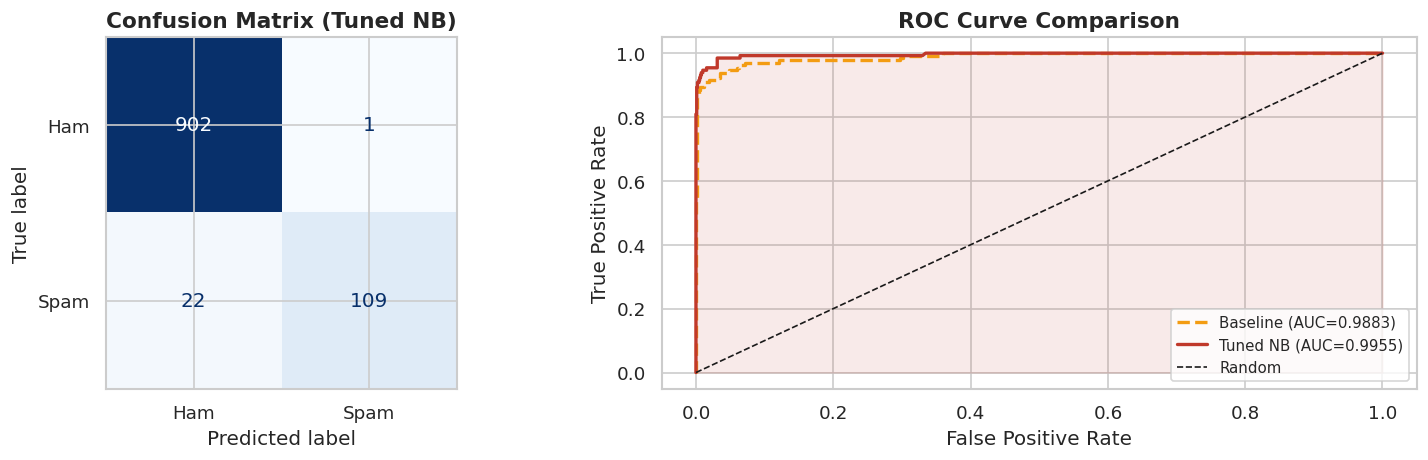

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Tuned NB)',
                  fontsize=13, fontweight='bold')

# ROC Curve
fpr_base, tpr_base, _ = roc_curve(
    y_test,
    nb_base.predict_proba(X_test_text)[:, 1])
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_prob)

axes[1].plot(fpr_base, tpr_base, color='#f39c12',
             lw=2, linestyle='--',
             label=f'Baseline (AUC={roc_base:.4f})')
axes[1].plot(fpr_best, tpr_best, color='#c0392b',
             lw=2,
             label=f'Tuned NB (AUC={roc:.4f})')
axes[1].fill_between(fpr_best, tpr_best,
                     alpha=0.1, color='#c0392b')
axes[1].plot([0,1],[0,1], 'k--', lw=1,
             label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('NB_10_confusion_roc.png',
            bbox_inches='tight')
plt.show()

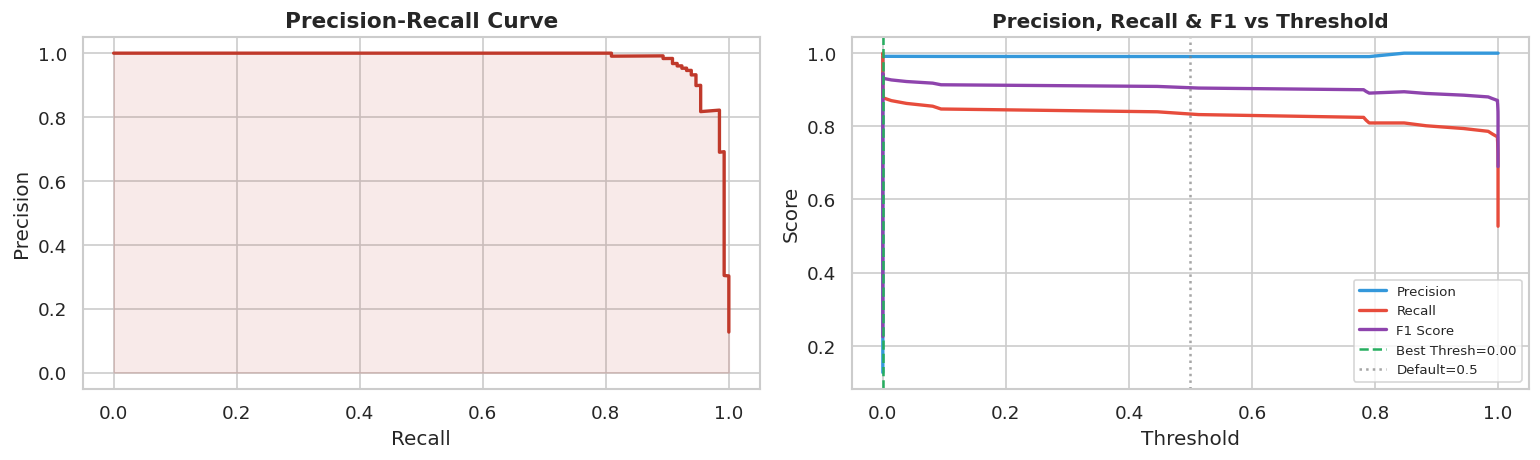

In [29]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(recall, precision,
             color='#c0392b', lw=2)
axes[0].fill_between(recall, precision,
                     alpha=0.1, color='#c0392b')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve',
                  fontsize=13, fontweight='bold')

# Threshold Analysis
f1_scores   = (2 * precision[:-1] * recall[:-1] /
               (precision[:-1] + recall[:-1] + 1e-8))
best_thresh = thresholds[np.argmax(f1_scores)]

axes[1].plot(thresholds, precision[:-1],
             color='#3498db', lw=2,
             label='Precision')
axes[1].plot(thresholds, recall[:-1],
             color='#e74c3c', lw=2,
             label='Recall')
axes[1].plot(thresholds, f1_scores,
             color='#8e44ad', lw=2,
             label='F1 Score')
axes[1].axvline(x=best_thresh, color='#27ae60',
                linestyle='--',
                label=f'Best Thresh='
                      f'{best_thresh:.2f}')
axes[1].axvline(x=0.5, color='gray',
                linestyle=':', alpha=0.7,
                label='Default=0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall & F1 vs Threshold',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('NB_11_precision_recall.png',
            bbox_inches='tight')
plt.show()

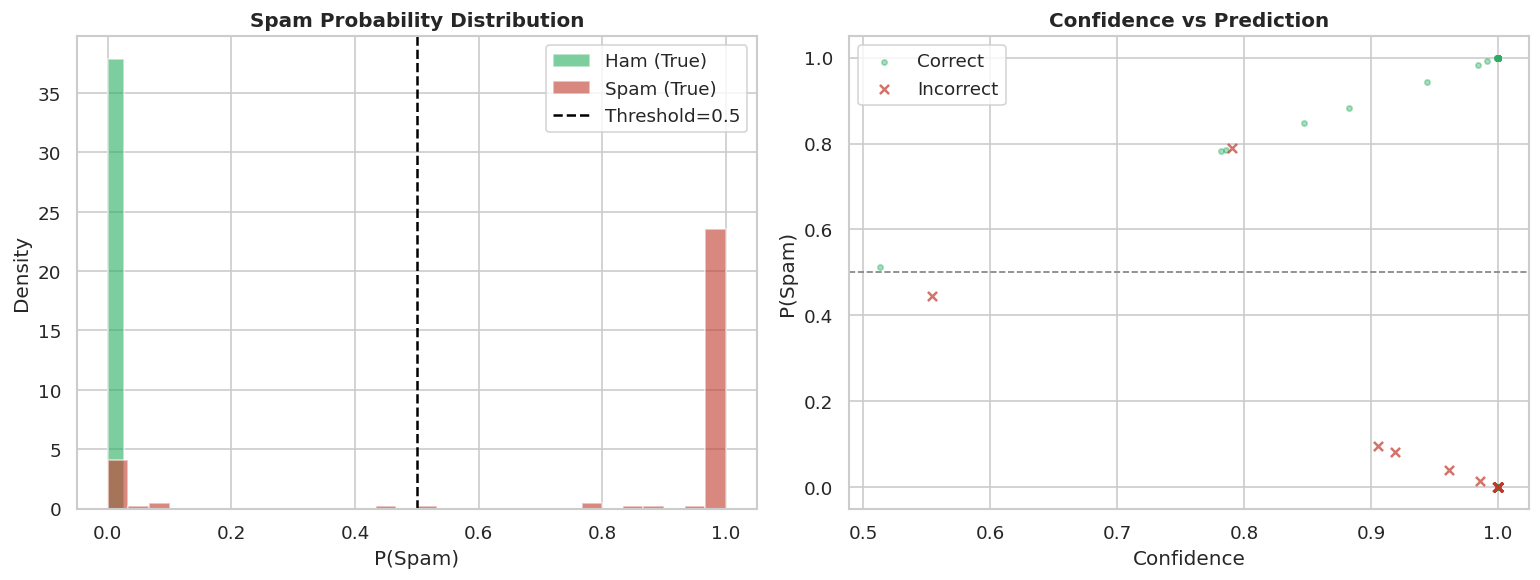

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Spam probability distribution
axes[0].hist(
    y_pred_prob[y_test == 0],
    bins=30, alpha=0.6,
    color='#27ae60', label='Ham (True)',
    density=True)
axes[0].hist(
    y_pred_prob[y_test == 1],
    bins=30, alpha=0.6,
    color='#c0392b', label='Spam (True)',
    density=True)
axes[0].axvline(x=0.5, color='black',
                linestyle='--', lw=1.5,
                label='Threshold=0.5')
axes[0].set_title('Spam Probability Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(Spam)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Confidence Analysis
confidence   = np.maximum(y_pred_prob,
                           1 - y_pred_prob)
correct_mask = (y_pred == y_test.values)

axes[1].scatter(confidence[correct_mask],
                y_pred_prob[correct_mask],
                alpha=0.4, s=10,
                color='#27ae60',
                label='Correct')
axes[1].scatter(confidence[~correct_mask],
                y_pred_prob[~correct_mask],
                alpha=0.7, s=30,
                color='#c0392b',
                label='Incorrect', marker='x')
axes[1].axhline(y=0.5, color='gray',
                linestyle='--', lw=1)
axes[1].set_title('Confidence vs Prediction',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('P(Spam)')
axes[1].legend()

plt.tight_layout()
plt.savefig('NB_12_probability_dist.png',
            bbox_inches='tight')
plt.show()

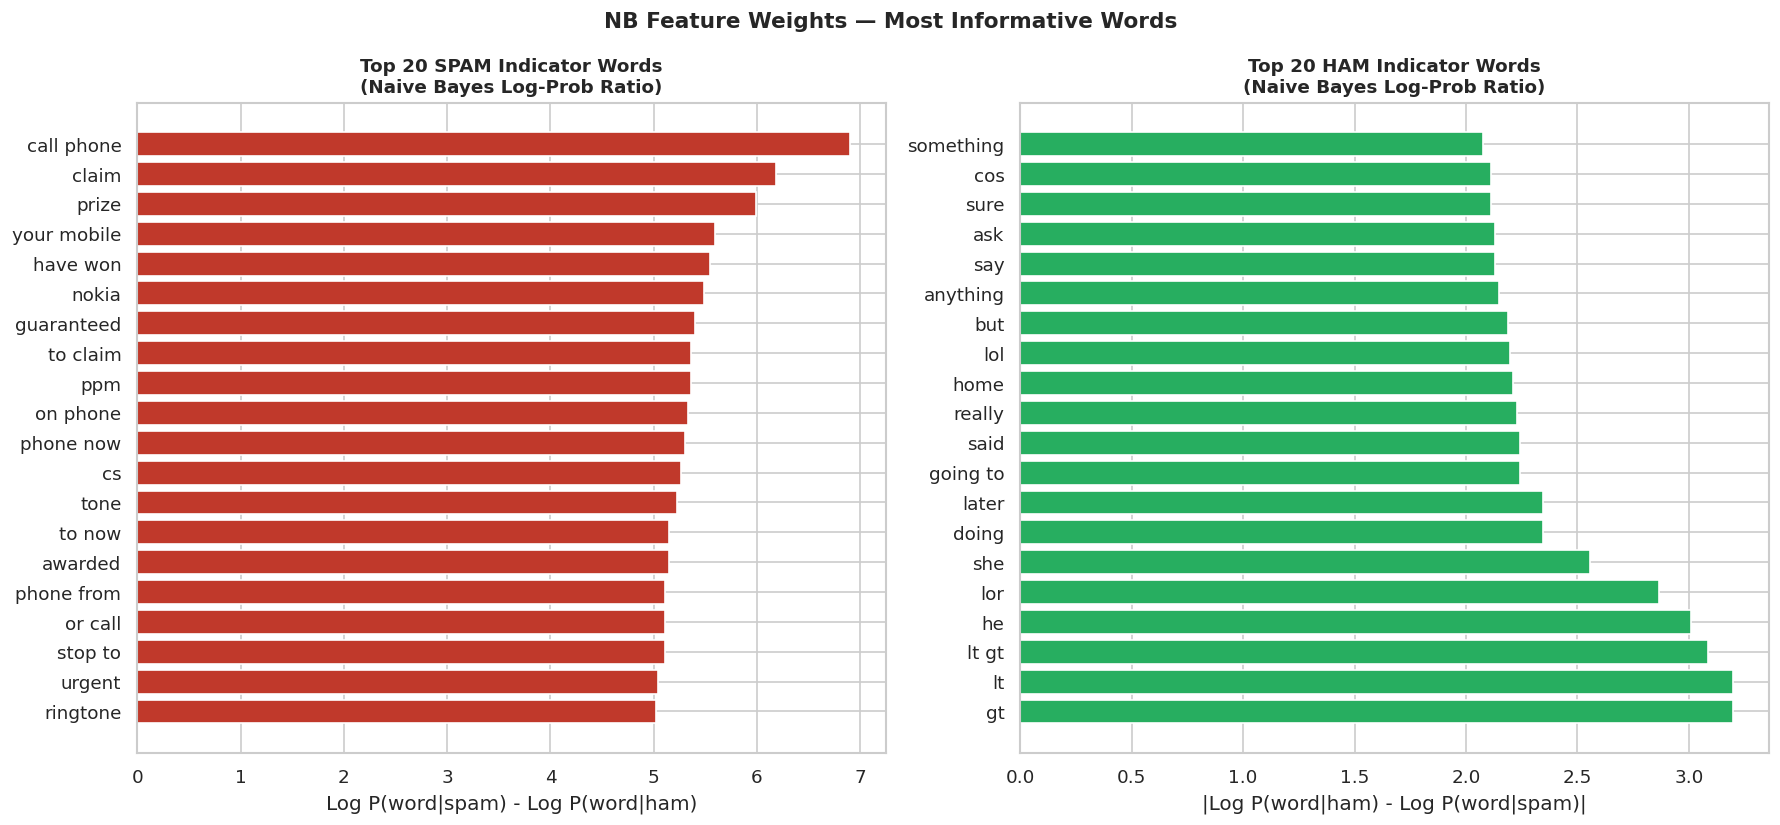

In [31]:
vectorizer_fitted = nb_best.named_steps['vectorizer']
nb_clf            = nb_best.named_steps['nb']

feature_names = vectorizer_fitted.get_feature_names_out()

# Log probability difference
log_prob = nb_clf.feature_log_prob_
spam_score = log_prob[1] - log_prob[0]

top_n = 20
top_spam_idx = spam_score.argsort()[-top_n:][::-1]
top_ham_idx  = spam_score.argsort()[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top Spam indicators
axes[0].barh(
    feature_names[top_spam_idx][::-1],
    spam_score[top_spam_idx][::-1],
    color='#c0392b', edgecolor='white')
axes[0].set_title('Top 20 SPAM Indicator Words\n'
                  '(Naive Bayes Log-Prob Ratio)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Log P(word|spam) - Log P(word|ham)')

# Top Ham indicators
axes[1].barh(
    feature_names[top_ham_idx],
    np.abs(spam_score[top_ham_idx]),
    color='#27ae60', edgecolor='white')
axes[1].set_title('Top 20 HAM Indicator Words\n'
                  '(Naive Bayes Log-Prob Ratio)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('|Log P(word|ham) - Log P(word|spam)|')

plt.suptitle('NB Feature Weights — '
             'Most Informative Words',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('NB_13_informative_words.png',
            bbox_inches='tight')
plt.show()

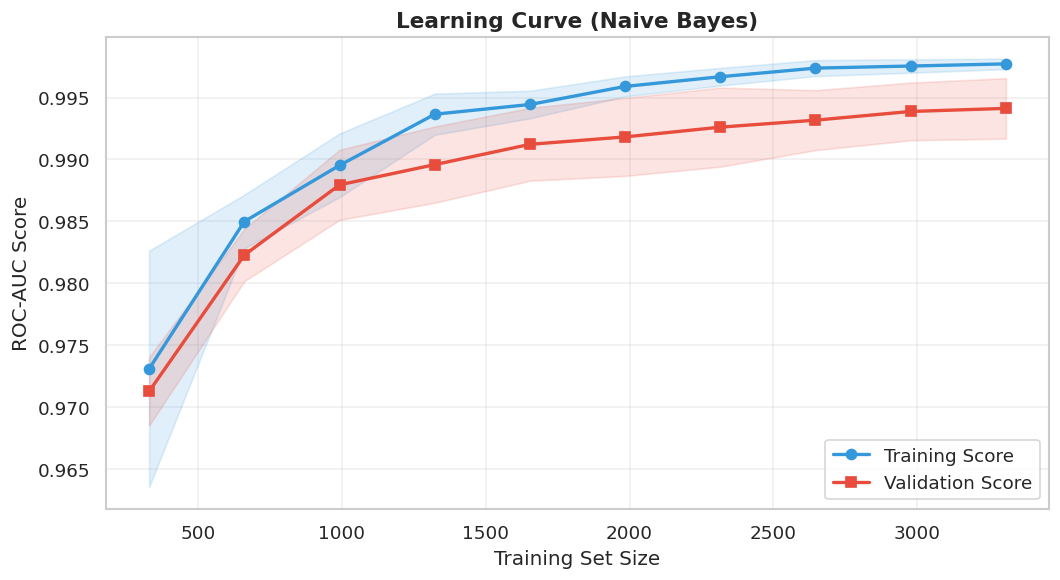

In [32]:
train_sizes, train_sc, val_sc = learning_curve(
    nb_best, X_train_text, y_train,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv          = StratifiedKFold(5),
    scoring     = 'roc_auc',
    n_jobs      = -1)

train_mean = train_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_mean   = val_sc.mean(axis=1)
val_std    = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-',
        color='#3498db', lw=2,
        label='Training Score')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean, 's-',
        color='#e74c3c', lw=2,
        label='Validation Score')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#e74c3c')
ax.set_title('Learning Curve (Naive Bayes)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC Score')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NB_14_learning_curve.png',
            bbox_inches='tight')
plt.show()

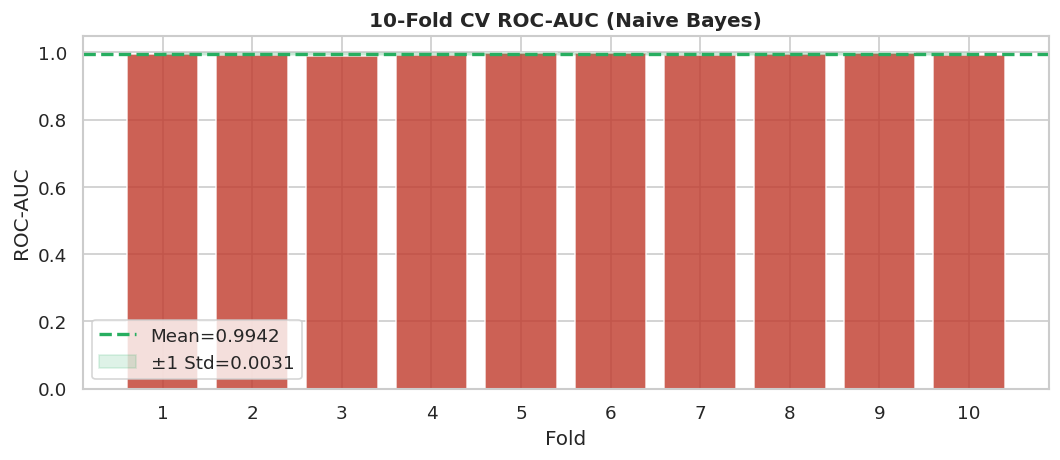

In [33]:
cv_scores_10 = cross_val_score(
    nb_best, X_train_text, y_train,
    cv=StratifiedKFold(10),
    scoring='roc_auc')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores_10,
       color='#c0392b', edgecolor='white',
       alpha=0.8)
ax.axhline(y=cv_scores_10.mean(),
           color='#27ae60', linestyle='--', lw=2,
           label=f'Mean={cv_scores_10.mean():.4f}')
ax.fill_between(
    range(1, 11),
    cv_scores_10.mean() - cv_scores_10.std(),
    cv_scores_10.mean() + cv_scores_10.std(),
    alpha=0.15, color='#27ae60',
    label=f'±1 Std={cv_scores_10.std():.4f}')
ax.set_title('10-Fold CV ROC-AUC (Naive Bayes)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('NB_15_cv_scores.png', bbox_inches='tight')
plt.show()

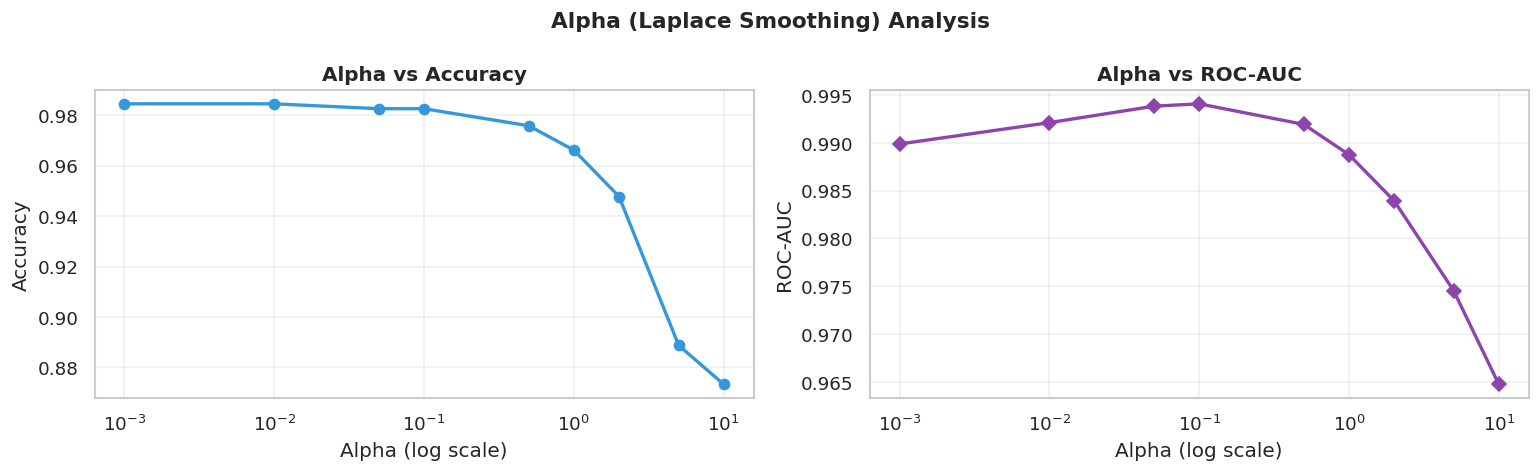

In [34]:
alphas     = [0.001, 0.01, 0.05, 0.1,
              0.5, 1.0, 2.0, 5.0, 10.0]
alpha_accs = []
alpha_rocs = []

for alpha in alphas:
    nb_alpha = Pipeline([
        ('vec', TfidfVectorizer(
            max_features = grid_search.best_params_.get(
                'vectorizer__max_features', 5000),
            ngram_range  = grid_search.best_params_.get(
                'vectorizer__ngram_range', (1,2)),
            sublinear_tf = True,
            max_df       = 0.95)),
        ('nb', MultinomialNB(alpha=alpha))
    ])
    nb_alpha.fit(X_train_text, y_train)
    y_pa = nb_alpha.predict(X_test_text)
    y_pp = nb_alpha.predict_proba(X_test_text)[:, 1]

    alpha_accs.append(accuracy_score(y_test, y_pa))
    alpha_rocs.append(roc_auc_score(y_test, y_pp))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(alphas, alpha_accs, 'o-',
                 color='#3498db', lw=2)
axes[0].set_title('Alpha vs Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(alphas, alpha_rocs, 'D-',
                 color='#8e44ad', lw=2)
axes[1].set_title('Alpha vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('ROC-AUC')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Alpha (Laplace Smoothing) Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('NB_16_alpha_analysis.png',
            bbox_inches='tight')
plt.show()

In [35]:
test_messages = [
    "FREE entry in 2 a wkly comp to win FA Cup "
    "final tkts 21st May 2005.",
    "Hey, are we still meeting for lunch tomorrow?",
    "WINNER!! As a valued network customer you have "
    "been selected to receive a £900 prize reward!",
    "Ok lar... Joking wif u oni...",
    "Congratulations! You've won a FREE iPhone. "
    "Click here to claim now!!!",
    "Can you pick up milk on the way home?",
    "URGENT: Your account will be suspended. "
    "Verify now at http://fake-bank.com",
    "See you at the party tonight!"
]

print(f"\n{'#':<3} {'Label':<12} {'Confidence':>12}"
      f"  Message")
print("-" * 70)

for i, msg in enumerate(test_messages):
    cleaned  = clean_text(msg)
    pred     = nb_best.predict([cleaned])[0]
    prob     = nb_best.predict_proba([cleaned])[0]
    label    = "🔴 SPAM" if pred == 1 else "🟢 HAM"
    conf     = prob.max() * 100
    print(f"{i+1:<3} {label:<12} {conf:>10.1f}%"
          f"  {msg[:45]}...")


#   Label          Confidence  Message
----------------------------------------------------------------------
1   🔴 SPAM            100.0%  FREE entry in 2 a wkly comp to win FA Cup fin...
2   🟢 HAM             100.0%  Hey, are we still meeting for lunch tomorrow?...
3   🔴 SPAM            100.0%  WINNER!! As a valued network customer you hav...
4   🟢 HAM             100.0%  Ok lar... Joking wif u oni......
5   🔴 SPAM             85.4%  Congratulations! You've won a FREE iPhone. Cl...
6   🟢 HAM             100.0%  Can you pick up milk on the way home?...
7   🟢 HAM              97.0%  URGENT: Your account will be suspended. Verif...
8   🟢 HAM             100.0%  See you at the party tonight!...


In [36]:
# Save full pipeline (vectorizer + NB)
joblib.dump(nb_best, 'nb_spam_pipeline.pkl')
print("✅ NB Pipeline saved   → nb_spam_pipeline.pkl")

# Save baseline
joblib.dump(nb_base, 'nb_spam_baseline.pkl')
print("✅ Baseline saved      → nb_spam_baseline.pkl")

# Save label encoder
joblib.dump(le, 'NB_label_encoder.pkl')
print("✅ Label encoder saved → NB_label_encoder.pkl")

# Save GridSearch results
pd.DataFrame(
    grid_search.cv_results_
).to_csv('NB_gridsearch_results.csv', index=False)
print("✅ GridSearch saved    → NB_gridsearch_results.csv")

# Save alpha analysis
pd.DataFrame({
    'alpha'   : alphas,
    'accuracy': alpha_accs,
    'roc_auc' : alpha_rocs
}).to_csv('NB_alpha_analysis.csv', index=False)
print("✅ Alpha analysis saved → NB_alpha_analysis.csv")

# Save top informative words
top_spam_words = pd.DataFrame({
    'word'      : feature_names[top_spam_idx],
    'spam_score': spam_score[top_spam_idx],
    'type'      : 'spam'
})
top_ham_words = pd.DataFrame({
    'word'      : feature_names[top_ham_idx],
    'spam_score': spam_score[top_ham_idx],
    'type'      : 'ham'
})
top_words_df = pd.concat(
    [top_spam_words, top_ham_words])
top_words_df.to_csv('NB_top_words.csv', index=False)
print("✅ Top words saved     → NB_top_words.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('nb_spam_pipeline.pkl')
    files.download('nb_spam_baseline.pkl')
    files.download('NB_label_encoder.pkl')
    files.download('NB_gridsearch_results.csv')
    files.download('NB_alpha_analysis.csv')
    files.download('NB_top_words.csv')
    print("\n🎉 All files downloaded to your PC!")
except ImportError:
    print("\n📁 Not in Colab — saved in current directory:")
    print(f"   → {os.path.abspath('nb_spam_pipeline.pkl')}")
    print(f"   → {os.path.abspath('NB_label_encoder.pkl')}")

✅ NB Pipeline saved   → nb_spam_pipeline.pkl
✅ Baseline saved      → nb_spam_baseline.pkl
✅ Label encoder saved → NB_label_encoder.pkl
✅ GridSearch saved    → NB_gridsearch_results.csv
✅ Alpha analysis saved → NB_alpha_analysis.csv
✅ Top words saved     → NB_top_words.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded to your PC!


In [37]:
loaded_pipeline = joblib.load('nb_spam_pipeline.pkl')

sample_msgs = X_test_text.iloc[:5].tolist()
predictions = loaded_pipeline.predict(sample_msgs)
proba       = loaded_pipeline.predict_proba(
    sample_msgs)[:, 1]
actuals     = y_test.values[:5]

print("\n📊 Sample Predictions:")
print(f"{'#':<4} {'Prediction':<14} "
      f"{'P(Spam)':>10} {'Actual':>10}")
print("-" * 42)

for i, (pred, prob, actual) in enumerate(
        zip(predictions, proba, actuals)):
    label    = "🔴 SPAM" if pred   == 1 else "🟢 HAM"
    act_lbl  = "SPAM"   if actual == 1 else "HAM"
    correct  = "✅" if pred == actual else "❌"
    print(f"{i+1:<4} {label:<14} "
          f"{prob*100:>9.2f}% {act_lbl:>8} {correct}")

print("\n✅ Model loaded and working perfectly!")


📊 Sample Predictions:
#    Prediction        P(Spam)     Actual
------------------------------------------
1    🟢 HAM               0.00%      HAM ✅
2    🟢 HAM               0.00%      HAM ✅
3    🟢 HAM               0.00%      HAM ✅
4    🟢 HAM               0.00%      HAM ✅
5    🟢 HAM               0.00%      HAM ✅

✅ Model loaded and working perfectly!


In [38]:
print(f"  Dataset              : SMS Spam Collection")
print(f"  Dataset Shape        : {df.shape}")
print(f"  Total Messages       : {len(df)}")
print(f"  Ham Messages         : {(df['label']=='ham').sum()}")
print(f"  Spam Messages        : {(df['label']=='spam').sum()}")
print(f"  Vocabulary Size      : {len(tfidf.vocabulary_)}")
print(f"  Best NB Variant      : {best_variant}")
print(f"  Best Parameters      : {grid_search.best_params_}")
print(f"  Baseline Accuracy    : {acc_base*100:.2f}%")
print(f"  Tuned Accuracy       : {acc*100:.2f}%")
print(f"  Baseline ROC-AUC     : {roc_base:.4f}")
print(f"  Tuned ROC-AUC        : {roc:.4f}")
print(f"  CV ROC-AUC           : "
      f"{cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Best F1 Threshold    : {best_thresh:.4f}")

print(" Saved Files:")
print("   nb_spam_pipeline.pkl   ← Production use!")
print("   nb_spam_baseline.pkl")
print("    NB_label_encoder.pkl")
print("   NB_gridsearch_results.csv")
print("   NB_alpha_analysis.csv")
print("   NB_top_words.csv")
print("    NB_01 ~ NB_16 PNG files")


  Dataset              : SMS Spam Collection
  Dataset Shape        : (5169, 16)
  Total Messages       : 5169
  Ham Messages         : 4516
  Spam Messages        : 653
  Vocabulary Size      : 5000
  Best NB Variant      : BernoulliNB (TF-IDF)
  Best Parameters      : {'nb__alpha': 1.0, 'nb__binarize': 0.0, 'vectorizer__max_features': 8000, 'vectorizer__ngram_range': (1, 2)}
  Baseline Accuracy    : 95.55%
  Tuned Accuracy       : 97.78%
  Baseline ROC-AUC     : 0.9883
  Tuned ROC-AUC        : 0.9955
  CV ROC-AUC           : 0.9941 ± 0.0024
  Best F1 Threshold    : 0.0000
 Saved Files:
   nb_spam_pipeline.pkl   ← Production use!
   nb_spam_baseline.pkl
    NB_label_encoder.pkl
   NB_gridsearch_results.csv
   NB_alpha_analysis.csv
   NB_top_words.csv
    NB_01 ~ NB_16 PNG files
